In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Iris.csv to Iris.csv


In [ ]:
df = pd.read_csv('Iris.csv')

In [ ]:
print("Dataset Dimensions (Rows, Columns):", df.shape)

Dataset Dimensions (Rows, Columns): (150, 6)


In [ ]:
print("\nMissing Values per Column:")
print(df.isnull().sum())


Missing Values per Column:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [ ]:
features = [
    'SepalLengthCm',
    'SepalWidthCm',
    'PetalLengthCm',
    'PetalWidthCm'
]
X = df[features]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
linked = linkage(X_scaled, method='ward')

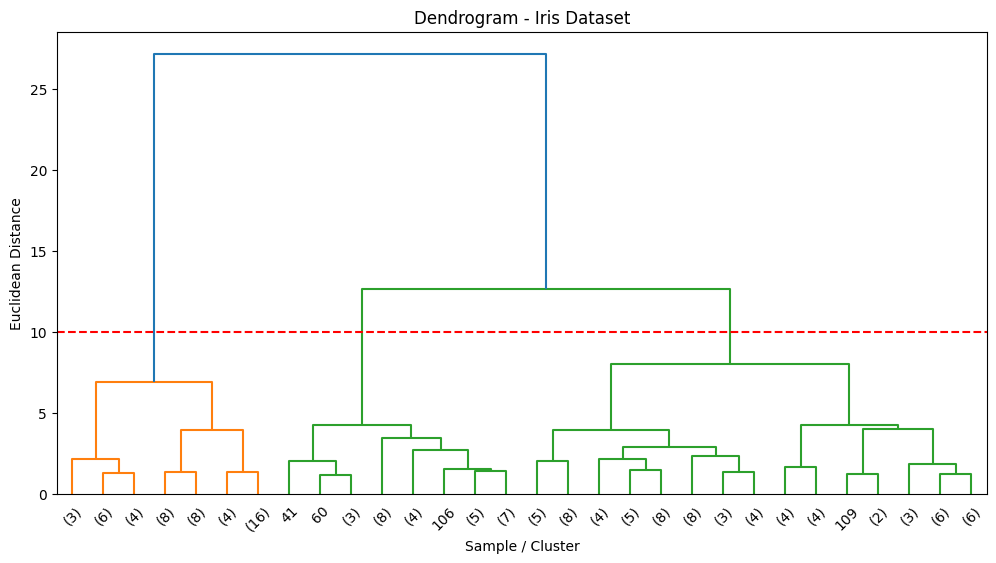

In [ ]:
plt.figure(figsize=(12, 6))
dendrogram(
    linked,
    truncate_mode='lastp',
    p=30
)
plt.axhline(y=10, color='r', linestyle='--')
plt.title('Dendrogram - Iris Dataset')
plt.xlabel('Sample / Cluster')
plt.ylabel('Euclidean Distance')
plt.show()

In [ ]:
model = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='ward'
)
labels = model.fit_predict(X_scaled)

In [ ]:
df['Cluster'] = labels

In [ ]:
print("\nSample counts per cluster:")
print(df['Cluster'].value_counts().sort_index())


Sample counts per cluster:
Cluster
0    71
1    49
2    30
Name: count, dtype: int64


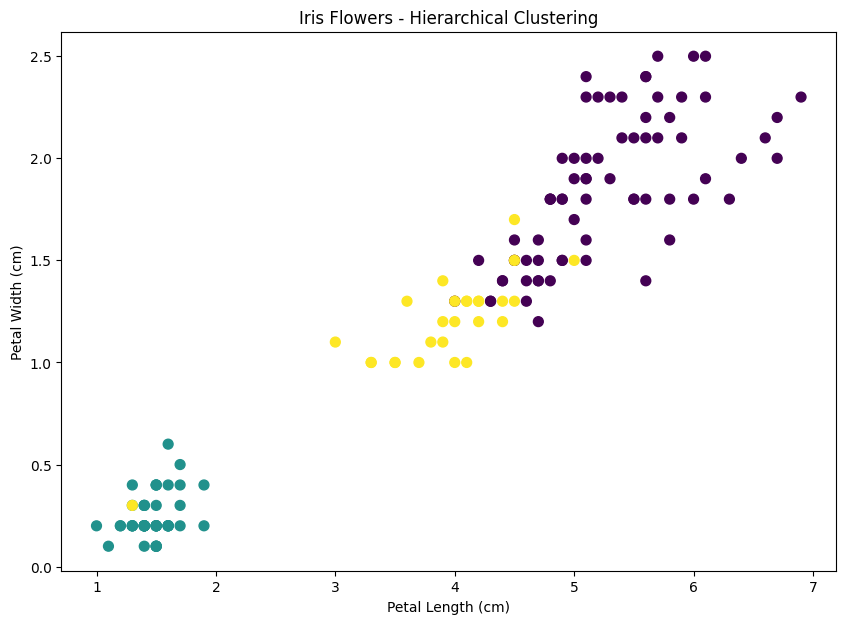

In [ ]:
plt.figure(figsize=(10, 7))
plt.scatter(
    df['PetalLengthCm'],
    df['PetalWidthCm'],
    c=labels,
    cmap='viridis',
    s=50
)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Iris Flowers - Hierarchical Clustering')
plt.show()

In [ ]:
comparison_table = pd.crosstab(df['Cluster'], df['Species'])
print("\nComparison Matrix (Cluster vs Actual Species):")
print(comparison_table)


Comparison Matrix (Cluster vs Actual Species):
Species  Iris-setosa  Iris-versicolor  Iris-virginica
Cluster                                              
0                  0               23              48
1                 49                0               0
2                  1               27               2
